# Monthly C[h,h] — Outlier Removal & Year-by-Year Table

**목적**: 각 월(4–9월)에 대해
1. h3/h4 IQR outlier day 식별 및 요약
2. Outlier 제거 후 연도별 C[h,h] 테이블 출력

**데이터**: GEMS TCO 2022–2025, lat [−3, 2], lon [121, 131]

In [1]:
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

warnings.filterwarnings('ignore')

sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")

YEARS     = ['2022', '2023', '2024', '2025']
MONTHS    = [4, 5, 6, 7, 8, 9]
N_SLOTS   = 8
SLOT_LABELS = [f'h{h}' for h in range(N_SLOTS)]
MONTH_NAMES = {4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep'}

CACHE_PATH = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/hourly_variability_sources/df_spatial_stats_cache.pkl")
assert CACHE_PATH.exists(), f"Cache not found: {CACHE_PATH}"
df_all = pd.read_pickle(CACHE_PATH)
print(f"Loaded: {len(df_all)} rows")
print(f"Columns: {list(df_all.columns)}")

Loaded: 5808 rows
Columns: ['year', 'month', 'day_idx', 'slot', 'hours_elapsed', 'spatial_mean', 'spatial_std', 'sem_lat_lag1', 'sem_lon_lag1', 'n_obs', 'spatial_mean_c']


In [2]:
def sample_cov_matrix(Y):
    n_s = Y.shape[1]
    C = np.full((n_s, n_s), np.nan)
    for h1 in range(n_s):
        for h2 in range(n_s):
            mask = np.isfinite(Y[:, h1]) & np.isfinite(Y[:, h2])
            if mask.sum() > 1:
                C[h1, h2] = np.mean(Y[mask, h1] * Y[mask, h2])
    return C


def build_Y(sub_df):
    """sub_df: data for one (month, year) or (month, all years). Returns Y (n_days × 8)."""
    day_order = (
        sub_df.groupby(['year', 'day_idx'])['hours_elapsed']
              .min().reset_index()
              .sort_values(['year', 'day_idx'])
    )
    mat_rows = []
    for _, row in day_order.iterrows():
        yr, d_idx = int(row['year']), int(row['day_idx'])
        s = sub_df[(sub_df['year'] == yr) & (sub_df['day_idx'] == d_idx)]
        vec = np.full(N_SLOTS, np.nan)
        for _, r in s.iterrows():
            vec[int(r['slot'])] = r['spatial_mean_c']
        mat_rows.append(vec)
    return np.array(mat_rows)


def find_outlier_days(df_mo, slots_to_check=None, iqr_mult=1.5):
    """
    slots_to_check: list of slot indices to apply IQR test (default: all 8)
    Returns set of (year, day_idx) tuples that are outliers in ANY of those slots.
    """
    if slots_to_check is None:
        slots_to_check = list(range(N_SLOTS))
    outlier_days = set()
    details = []
    for slot in slots_to_check:
        sub_slot = df_mo[df_mo['slot'] == slot]['spatial_mean_c'].dropna()
        q1, q3 = sub_slot.quantile(0.25), sub_slot.quantile(0.75)
        iqr = q3 - q1
        upper = q3 + iqr_mult * iqr
        lower = q1 - iqr_mult * iqr
        mask = (df_mo['slot'] == slot) & (
            (df_mo['spatial_mean_c'] > upper) | (df_mo['spatial_mean_c'] < lower)
        )
        for _, r in df_mo[mask].iterrows():
            key = (int(r['year']), int(r['day_idx']))
            outlier_days.add(key)
            details.append({
                'slot': f'h{slot}', 'year': int(r['year']),
                'day_idx': int(r['day_idx']),
                'val': round(r['spatial_mean_c'], 2),
                'upper': round(upper, 2), 'lower': round(lower, 2)
            })
    return outlier_days, pd.DataFrame(details).sort_values(['year','day_idx','slot']) if details else pd.DataFrame()


def print_cov_table(yearly_C, yearly_n, header=""):
    """Print C[h,h] table in the target style."""
    if header:
        print(header)
    for yr in YEARS:
        if yr not in yearly_C:
            continue
        diag = np.diag(yearly_C[yr])
        n = yearly_n.get(yr, '?')
        parts = "  ".join(f"{SLOT_LABELS[h]}={diag[h]:.2f}" for h in range(N_SLOTS))
        print(f"{yr}  ({n} days)")
        print(f"  C[h,h]: {parts}")
        print()

print("Helpers ready.")

Helpers ready.


---
## Main Analysis — Month by Month (Apr–Sep)

In [3]:
# ── Month-by-month: outlier summary + clean C[h,h] table ─────────────────────
#
# Outlier detection: IQR on ALL 8 slots (catches any slot with extreme values)
# A 'day' is flagged if ANY of its slots is an outlier.

all_results = {}   # store for later plotting

for mo in MONTHS:
    df_mo = df_all[df_all['month'] == mo].copy()
    mname = MONTH_NAMES[mo]

    print("=" * 70)
    print(f"  {mname} (month={mo})")
    print("=" * 70)

    # ── Step 1: find outlier days (IQR across all slots) ──────────────────────
    outlier_days, df_details = find_outlier_days(df_mo, slots_to_check=list(range(N_SLOTS)))

    if len(outlier_days) == 0:
        print("  No outlier days detected.\n")
    else:
        print(f"  Outlier days ({len(outlier_days)} unique days):")
        for yr_key, d_key in sorted(outlier_days):
            # which slots triggered, and their values
            triggered = df_details[(df_details['year'] == yr_key) & (df_details['day_idx'] == d_key)]
            slot_info = ", ".join(
                f"{r['slot']}={r['val']} (bounds [{r['lower']}, {r['upper']}])"
                for _, r in triggered.iterrows()
            )
            print(f"    year={yr_key}  day_idx={d_key}  →  {slot_info}")
        print()

    # ── Step 2: remove outlier days ───────────────────────────────────────────
    if outlier_days:
        keep_mask = ~df_mo.apply(
            lambda r: (int(r['year']), int(r['day_idx'])) in outlier_days, axis=1
        )
        df_clean = df_mo[keep_mask].copy()
    else:
        df_clean = df_mo.copy()

    # ── Step 3: compute C per year (clean) ────────────────────────────────────
    yearly_C_clean = {}
    yearly_n_clean = {}
    for yr in YEARS:
        sub = df_clean[df_clean['year'] == int(yr)]
        if len(sub) == 0:
            continue
        Y = build_Y(sub)
        yearly_n_clean[yr] = Y.shape[0]
        yearly_C_clean[yr] = sample_cov_matrix(Y)

    # ── Step 4: print table ───────────────────────────────────────────────────
    print(f"  C[h,h] after outlier removal:") 
    print()
    print_cov_table(yearly_C_clean, yearly_n_clean)

    all_results[mo] = {
        'outlier_days': outlier_days,
        'yearly_C_clean': yearly_C_clean,
        'yearly_n_clean': yearly_n_clean,
    }

  Apr (month=4)
  Outlier days (3 unique days):
    year=2023  day_idx=19  →  h3=35.72 (bounds [-8.18, 7.32]), h4=96.56 (bounds [-8.0, 7.08])
    year=2024  day_idx=17  →  h0=10.83 (bounds [-7.61, 7.36]), h1=8.83 (bounds [-7.64, 6.99])
    year=2024  day_idx=29  →  h0=9.01 (bounds [-7.61, 7.36]), h1=12.64 (bounds [-7.64, 6.99]), h2=13.13 (bounds [-8.07, 7.27]), h3=13.0 (bounds [-8.18, 7.32]), h4=13.06 (bounds [-8.0, 7.08]), h5=13.28 (bounds [-7.55, 7.35]), h6=12.81 (bounds [-7.68, 7.38]), h7=13.26 (bounds [-6.15, 8.41])

  C[h,h] after outlier removal:

2022  (30 days)
  C[h,h]: h0=4.79  h1=4.98  h2=5.56  h3=5.64  h4=5.16  h5=5.16  h6=5.13  h7=5.56

2023  (29 days)
  C[h,h]: h0=7.65  h1=7.88  h2=8.53  h3=8.69  h4=8.28  h5=7.74  h6=7.84  h7=7.87

2024  (28 days)
  C[h,h]: h0=8.92  h1=10.38  h2=10.64  h3=11.00  h4=11.21  h5=10.44  h6=10.33  h7=10.98

2025  (30 days)
  C[h,h]: h0=5.62  h1=5.63  h2=6.09  h3=6.09  h4=5.72  h5=5.58  h6=5.33  h7=7.05

  May (month=5)
  Outlier days (1 unique 

Based on the data provided, here is a concise summary:

Key Findings: Diurnal Patterns
Dominant Trend: A consistent spike at h7 is observed across most months and years. This trend is particularly rigid in June, July, and September, where C[h,h] at h7 often doubles the preceding values.

Monthly Consistency: * High: June and July show the most stable year-over-year diurnal shapes.

Low: August is the primary exception; in 2022, the peak shifted to h4, and the h7 spike vanished.

Variance Baselines: May and September exhibit higher overall variance (≈12−18) compared to the relatively calmer April and June (≈5−10).

Outlier Behavior: Outliers are often "systemic" (the entire day shifts upward) rather than single-hour glitches, suggesting broad daily geophysical or technical fluctuations.

Conclusion: There is a reliable diurnal pattern centered on an h7 peak, though its intensity fluctuates seasonally and August remains a notable anomaly.

2. English Summary (Focusing on June & July vs. Others)

Compared to the highly predictable June and July, other months exhibit much higher volatility and less stable diurnal shapes.

June & July (The "Stable" Months):

Linear Growth: Feature a very calm baseline from h0 to h2, followed by a steady linear increase.

Predictable Surge: The jump from h6 to h7 is consistent and follows a similar ratio every year.

Low Volatility: The overall variance levels (C[h,h]) stay within a tight range (mostly 4–10).

Other Months (The "Volatile" Months):

Baseline Shifts: May and September show massive shifts in baseline variance (15+ vs 5), making them harder to model.

August Anomaly: August frequently breaks the "h7 peak" rule, with mid-day spikes (e.g., 2022 h4 peak).

Extreme Gradients: September has the most aggressive surges, but they are too erratic to be considered a "steady" pattern.

Conclusion: June and July are the only months that provide a reliable, "clean" diurnal signature suitable for stable statistical modeling. Other months require more complex, time-varying parameters due to their high noise and seasonal irregularities.

In [4]:
# ── Summary: outlier count per month ──────────────────────────────────────────
print("Outlier day count per month:")
print(f"{'Month':>6}  {'# outlier days':>15}")
for mo in MONTHS:
    n_out = len(all_results[mo]['outlier_days'])
    print(f"  {MONTH_NAMES[mo]:>4}   {n_out:>3}")

Outlier day count per month:
 Month   # outlier days
   Apr     3
   May     1
   Jun     1
   Jul     4
   Aug     2
   Sep     2


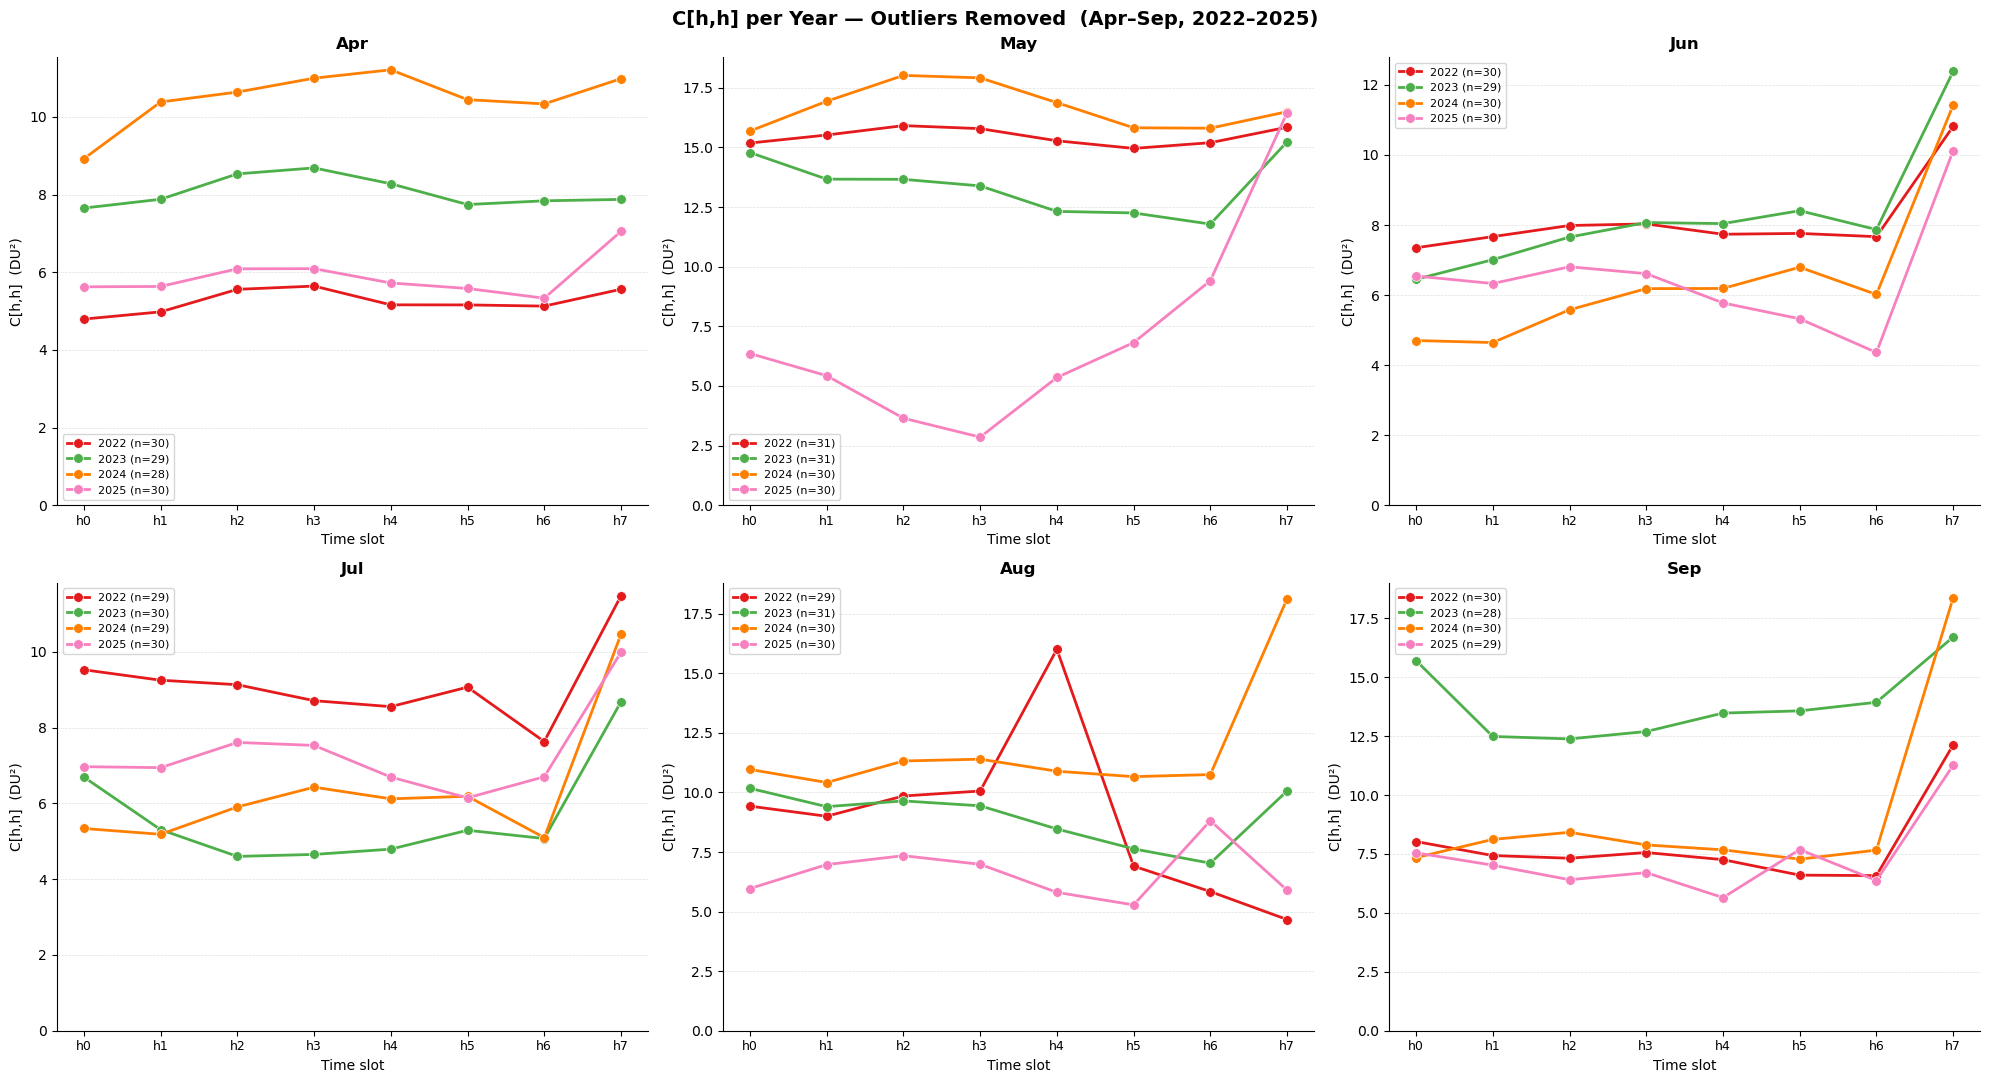

Saved → monthly_yearly_clean_diag.png


In [5]:
# ── Visualization: clean C[h,h] per month × year ──────────────────────────────
OUT_DIR = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/monthly_cov_clean/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

year_colors = plt.cm.Set1(np.linspace(0, 0.8, len(YEARS)))
YEAR_PAL = dict(zip(YEARS, year_colors))

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('C[h,h] per Year — Outliers Removed  (Apr–Sep, 2022–2025)',
             fontsize=14, fontweight='bold')

for ax, mo in zip(axes.ravel(), MONTHS):
    res = all_results[mo]
    for i, yr in enumerate(YEARS):
        if yr not in res['yearly_C_clean']:
            continue
        diag = np.diag(res['yearly_C_clean'][yr])
        n = res['yearly_n_clean'][yr]
        ax.plot(range(N_SLOTS), diag, 'o-',
                color=YEAR_PAL[yr], lw=2.0, ms=7,
                markeredgecolor='white', markeredgewidth=0.5,
                label=f'{yr} (n={n})', zorder=5+i)

    ax.set_title(MONTH_NAMES[mo], fontsize=12, fontweight='bold')
    ax.set_xticks(range(N_SLOTS)); ax.set_xticklabels(SLOT_LABELS, fontsize=9)
    ax.set_xlabel('Time slot', fontsize=10)
    ax.set_ylabel('C[h,h]  (DU²)', fontsize=10)
    ax.set_ylim(bottom=0)
    ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8, framealpha=0.8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'monthly_yearly_clean_diag.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → monthly_yearly_clean_diag.png")